In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load the raw data extracted during the Exploratory Data Analysis (EDA) step
df = pd.read_csv('../data/raw/ames_housing_raw.csv')

# 2. Data Cleaning: Drop columns containing more than 80% missing data values
# This prevents noisy, mostly empty features from corrupting model training matrices
columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'Id']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# 3. Separation of Variables: Isolate predictive features (X) from the target asset price (y)
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# 4. Data Partitioning: Stratify data into 80% Training and 20% Testing subsets
# The random_state parameter guarantees data split reproducibility across runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Target Optimization: Apply a natural logarithmic transformation plus one [log(x + 1)]
# Real estate prices are heavily right-skewed (skewed by rare multi-million dollar luxury assets).
# Transforming to a logarithmic scale stabilizes variance and ensures a normal distribution.
# This prevents extreme pricing outliers from biasing your predictive models.
y_train_log = np.log1p(y_train)

print(f"Cell 1 Complete! Training features shape: {X_train.shape}")
print("Target variable log transformation successfully completed.")


Cell 1 Complete! Training features shape: (1168, 74)
Target variable log transformation successfully completed.


In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Feature Classification: Automatically partition columns by data type
# Numeric columns represent quantitative features (e.g., Square Footage, Bathrooms)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
# Categorical columns represent qualitative descriptions (e.g., Neighborhood, Zoning Type)
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# 2. Quantitative Sub-Pipeline: Handle missing numeric values and scale features
# Imputation: Missing values are filled with the column's median to avoid outlier bias
# Scaling: Standardization centers data to a mean of 0 and a variance of 1 (Z-Score)
# This prevents high-magnitude features (like Lot Area) from dominating the models
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. Qualitative Sub-Pipeline: Handle missing categorical data and encode text
# Imputation: Missing values are filled with the mode (most frequent string occurrence)
# Encoding: One-Hot Encoding converts categories into distinct binary columns (0 or 1)
# sparse_output=False ensures a dense matrix compatible with all ensemble frameworks
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Column Transformation Matrix: Bind sub-pipelines into a single layout
# This orchestrator applies the correct processing steps to the matching columns in parallel
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Cell 2 Complete! Preprocessing and feature transformation pipeline successfully established.")


Cell 2 Complete! Preprocessing and feature transformation pipeline successfully established.


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor  # Advanced gradient boosting framework

# 1. Define Model Manifest: Construct dictionary of baseline models and advanced ensembles
# We include standard estimators alongside advanced Boosting and Bagging framework variants
models = {
    "Linear Regression (Baseline)": LinearRegression(),
    
    "Random Forest (Bagging Ensemble)": RandomForestRegressor(
        n_estimators=100, 
        random_state=42
    ),
    
    "Gradient Boosting (Boosting Ensemble)": GradientBoostingRegressor(
        n_estimators=100, 
        learning_rate=0.1, 
        random_state=42
    ),
    
    "XGBoost (Advanced Boosting)": XGBRegressor(
        n_estimators=100, 
        learning_rate=0.05, 
        max_depth=4, 
        random_state=42
    )
}

# Empty dictionary to store performance scores for final portfolio reporting
results = {}

print("--- Commencing Multi-Model Ensemble Evaluation Loop ---\n")

# 2. Execution Pipeline Loop: Train, Predict, and Inverse-Transform for each algorithm
for name, model in models.items():
    
    # Encapsulate preprocessing transformations and model training inside a single Scikit-Learn Pipeline
    # This prevents training-to-testing dataset leakage completely
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    # Fit the structural pipeline model using the log-transformed target variables calculated in Cell 1
    pipeline.fit(X_train, y_train_log)
    
    # Generate test subset predictions (Note: outputs will naturally be on a logarithmic scale)
    log_predictions = pipeline.predict(X_test)
    
    # Mathematical Reverse-Transformation: Apply the exponential function minus one [exp(x) - 1]
    # This reverts the log scale back into raw, interpretative USD value formats for clear auditing
    predictions = np.expm1(log_predictions)
    
    # 3. Structural Metric Diagnostics Calculation
    # Mean Absolute Error (MAE) displays the average real-dollar pricing error variation
    # Coefficient of Determination (R²) scores showcase the percentage proportion of structural variance explained
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    # Store calculations inside our results collector object
    results[name] = {"MAE": mae, "R2": r2}
    
    # Output metrics directly inside the VS Code Jupyter execution interface
    print(f"=== {name} ===")
    print(f"  -> Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"  -> R² Score (Variance Explained): {r2:.4f}\n")


--- Commencing Multi-Model Ensemble Evaluation Loop ---

=== Linear Regression (Baseline) ===
  -> Mean Absolute Error (MAE): $15,065.23
  -> R² Score (Variance Explained): 0.9312

=== Random Forest (Bagging Ensemble) ===
  -> Mean Absolute Error (MAE): $17,617.04
  -> R² Score (Variance Explained): 0.8889

=== Gradient Boosting (Boosting Ensemble) ===
  -> Mean Absolute Error (MAE): $16,800.84
  -> R² Score (Variance Explained): 0.8879

=== XGBoost (Advanced Boosting) ===
  -> Mean Absolute Error (MAE): $17,082.64
  -> R² Score (Variance Explained): 0.8859



Extracting feature importances from the Ensemble framework...


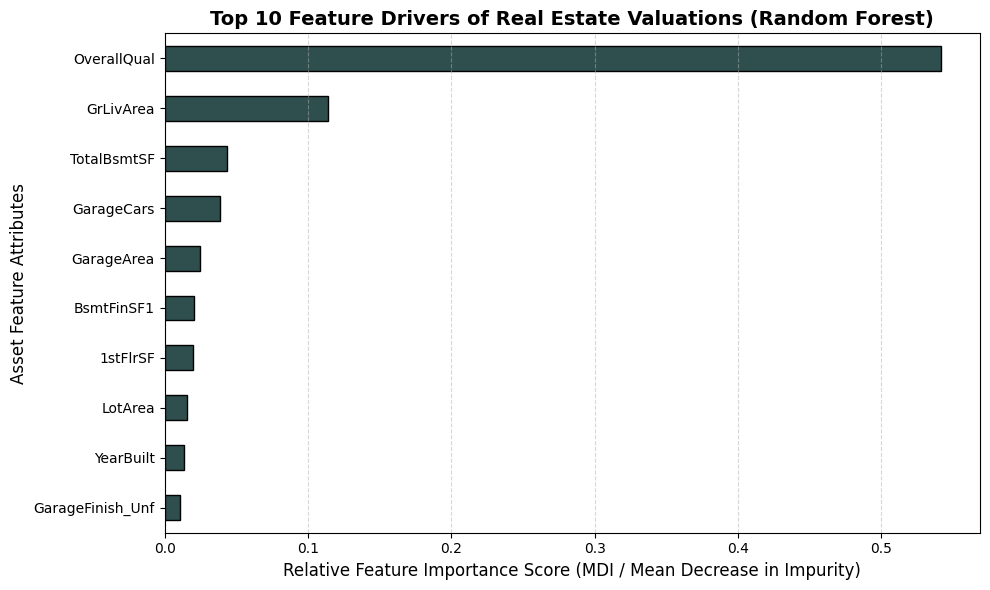


Top 5 Most Dominant Pricing Features:
OverallQual    0.541803
GrLivArea      0.113759
TotalBsmtSF    0.043325
GarageCars     0.038483
GarageArea     0.024990
dtype: float64


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Extracting feature importances from the Ensemble framework...")

# 1. Isolate and retrain the Random Forest model independently within a standalone pipeline
rf_model = models["Random Forest (Bagging Ensemble)"]
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', rf_model)])

# Fit using the log-transformed training set targets from Cell 1
rf_pipeline.fit(X_train, y_train_log)

# 2. Reconstruct column text headers from the One-Hot Encoder block inside Cell 2
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))

# Combine the raw continuous numeric features with the newly generated binary text features
all_features = list(numeric_features) + encoded_cat_features

# 3. Pull structural matrix metrics directly from the tree ensemble estimators
importances = rf_pipeline.named_steps['regressor'].feature_importances_

# 4. Map importances back to feature labels and isolate the top 10 pricing drivers
feat_importances = pd.Series(importances, index=all_features)
top_10_features = feat_importances.nlargest(10)

# 5. Render a professional academic bar chart visualization inside VS Code
plt.figure(figsize=(10, 6))

# FIXED: Replaced invalid color with 'darkslategray' for a crisp academic look
top_10_features.plot(kind='barh', color='darkslategray', edgecolor='black').invert_yaxis()

plt.title("Top 10 Feature Drivers of Real Estate Valuations (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Relative Feature Importance Score (MDI / Mean Decrease in Impurity)", fontsize=12)
plt.ylabel("Asset Feature Attributes", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print text backup summary of the top features for your report writing
print("\nTop 5 Most Dominant Pricing Features:")
print(top_10_features.head(5))
